In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Read image in grayscale
input_image_path = '/content/BrainProtonDensitySlice.png'
input_image = cv2.imread(input_image_path, cv2.IMREAD_GRAYSCALE)

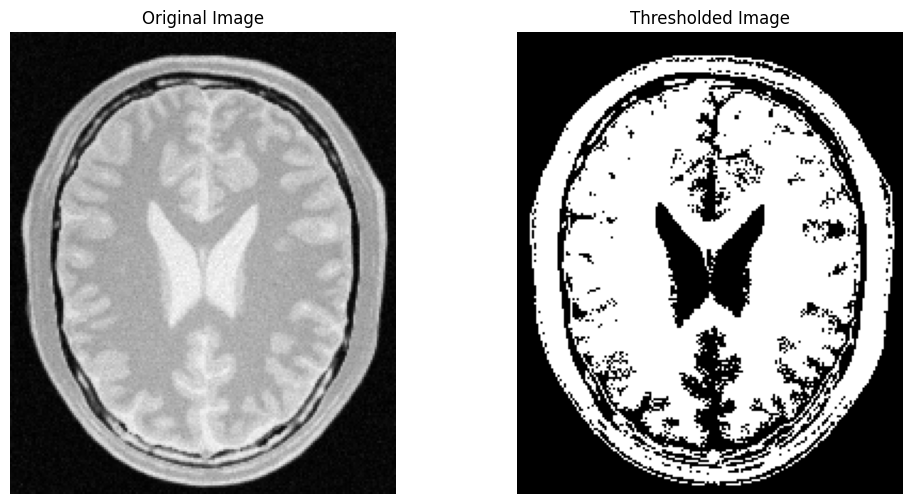

In [ ]:
# Parameters
lower_threshold = 100
upper_threshold = 200

inside_value = 255  # White (Foreground)
outside_value = 0  # Black (Background)

# Apply threshold ing
mask = cv2.inRange(input_image, lower_threshold, upper_threshold)

# Map the mask values to inside_value or outside_value
thresholded_image = cv2.threshold(mask, 0, inside_value, cv2.THRESH_BINARY)[1]

# Display thresholded image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(input_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(thresholded_image, cmap='gray')
axes[1].set_title('Thresholded Image')
axes[1].axis('off')

plt.show()


/tmp/ipython-input-1429914654.py:11: RuntimeWarning: overflow encountered in exp
  sigmoid_image = output_min + (output_max - output_min) / (1.0 + np.exp(alpha * (beta - img_float)))


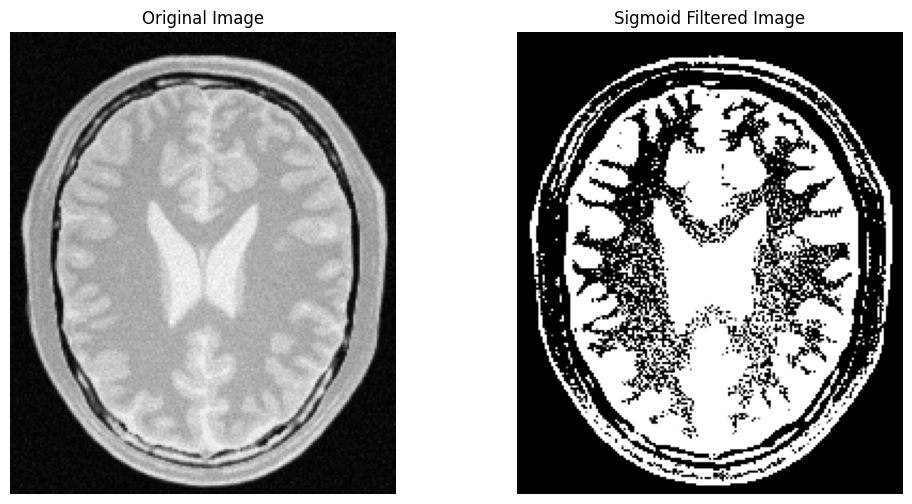

In [ ]:
# Sigmoid filter parameters
alpha = 10.0     # Steepness
beta = 170.0     # Midpoint intensity
output_min = 10.0
output_max = 240.0

# Convert to float for computation
img_float = input_image.astype(np.float32)

# Apply sigmoid formula
sigmoid_image = output_min + (output_max - output_min) / (1.0 + np.exp(alpha * (beta - img_float)))

# Clip and convert to uint8
sigmoid_image = np.clip(sigmoid_image, 0, 255).astype(np.uint8)

# Display original and processed images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(input_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(sigmoid_image, cmap='gray')
axes[1].set_title('Sigmoid Filtered Image')
axes[1].axis('off')

plt.show()


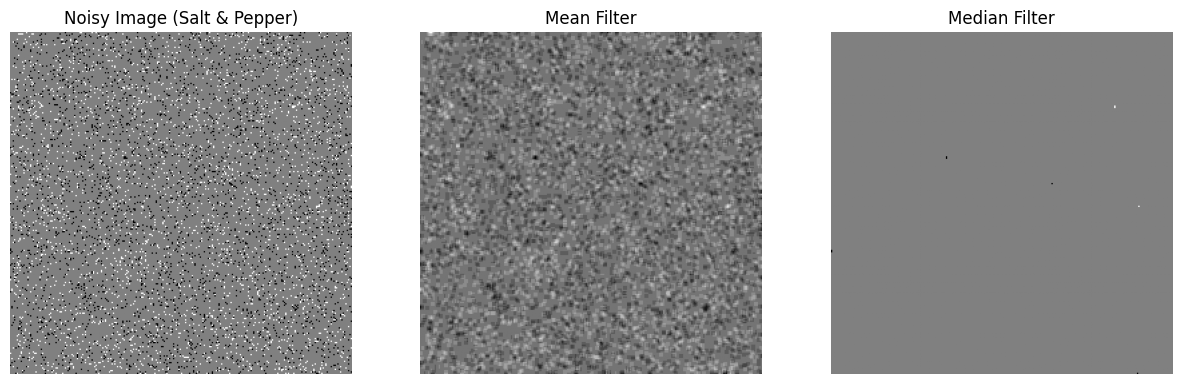

In [ ]:
# Function to add salt-and-pepper noise
def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    noisy_image = image.copy()
    # Salt noise
    salt_mask = np.random.rand(*image.shape) < salt_prob
    noisy_image[salt_mask] = 255
    # Pepper noise
    pepper_mask = np.random.rand(*image.shape) < pepper_prob
    noisy_image[pepper_mask] = 0
    return noisy_image

# Create a sample image
image_size = (256, 256)
image = np.full(image_size, 128, dtype=np.uint8)

# Add salt-and-pepper noise
salt_prob = 0.05
pepper_prob = 0.05
noisy_image = add_salt_and_pepper_noise(image, salt_prob, pepper_prob)

# Apply mean filter
kernel_size = (3, 3)
mean_filtered = cv2.blur(noisy_image, kernel_size)

# Apply median filter (using cv2.medianBlur)
median_filtered = cv2.medianBlur(noisy_image, 3)  # 3x3 kernel

# Plotting the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(noisy_image, cmap='gray')
axes[0].set_title('Noisy Image (Salt & Pepper)')
axes[0].axis('off')

axes[1].imshow(mean_filtered, cmap='gray')
axes[1].set_title('Mean Filter')
axes[1].axis('off')

axes[2].imshow(median_filtered, cmap='gray')
axes[2].set_title('Median Filter')
axes[2].axis('off')

plt.show()


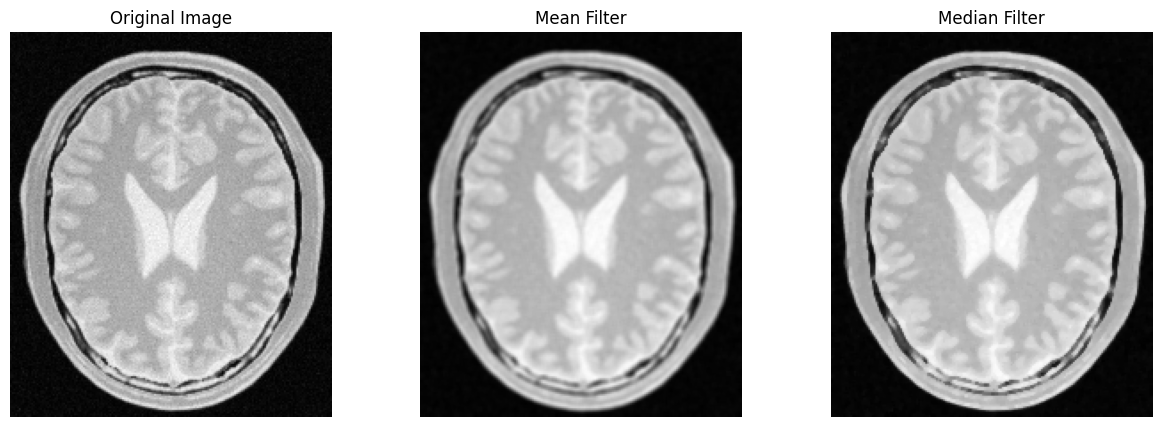

In [ ]:
# Apply fean filter
kernel_size = (3, 3)
mean_filtered = cv2.blur(input_image, kernel_size)

# Apply median filter
median_filtered = cv2.medianBlur(input_image, 3)  # 3x3 kernel

# Plotting the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(input_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(mean_filtered, cmap='gray')
axes[1].set_title('Mean Filter')
axes[1].axis('off')

axes[2].imshow(median_filtered, cmap='gray')
axes[2].set_title('Median Filter')
axes[2].axis('off')

plt.show()

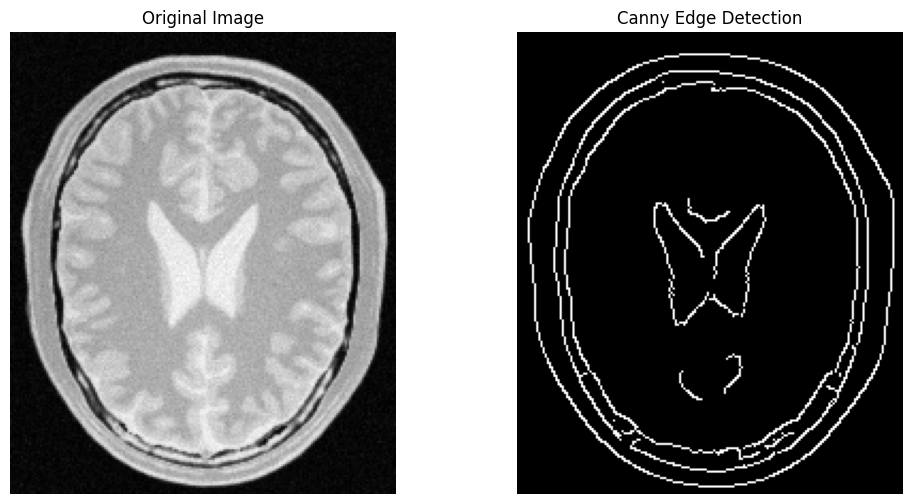

In [ ]:
# Parameters
lower_threshold = 0.1  # relative to 255
upper_threshold = 0.3
variance = 5.0  # Gaussian smoothing variance

# Apply Gaussian blur for noise reduction
sigma = variance ** 0.5
blurred_image = cv2.GaussianBlur(input_image, (0, 0), sigma)

# Apply Canny edge detection
edges = cv2.Canny(blurred_image, int(lower_threshold * 255), int(upper_threshold * 255))

# Display original and edge-detected images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(input_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edge Detected Image')
axes[1].axis('off')

plt.show()


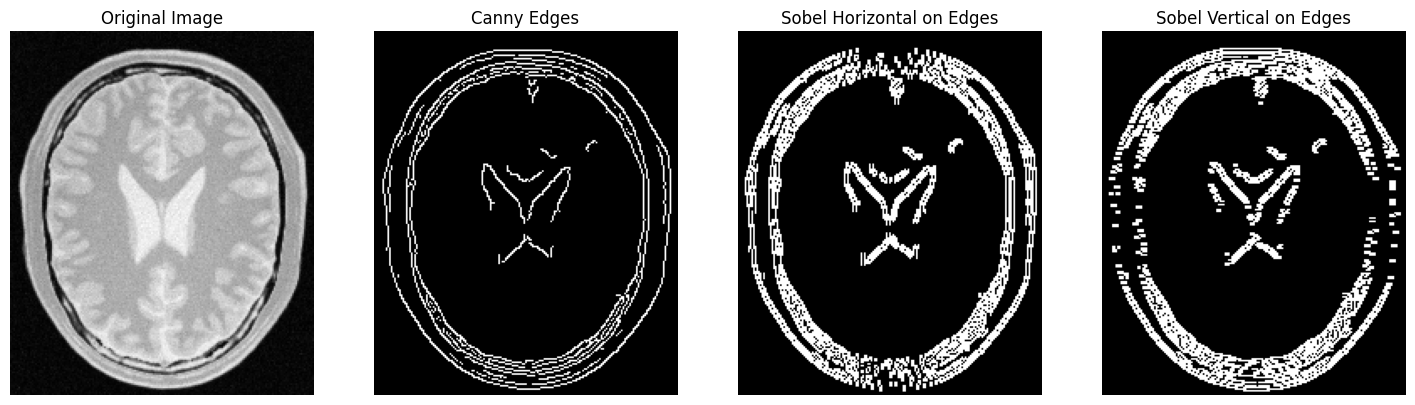

In [ ]:
# Apply Canny edge detection
edges = cv2.Canny(input_image, 120, 225)

# Apply Sobel kernels on the edges detected
sobel_horizontal = cv2.Sobel(edges, cv2.CV_64F, 1, 0, ksize=3)
sobel_horizontal = cv2.convertScaleAbs(sobel_horizontal)

sobel_vertical = cv2.Sobel(edges, cv2.CV_64F, 0, 1, ksize=3)
sobel_vertical = cv2.convertScaleAbs(sobel_vertical)

# Display results
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

axes[0].imshow(input_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edges')
axes[1].axis('off')

axes[2].imshow(sobel_horizontal, cmap='gray')
axes[2].set_title('Sobel Horizontal on Edges')
axes[2].axis('off')

axes[3].imshow(sobel_vertical, cmap='gray')
axes[3].set_title('Sobel Vertical on Edges')
axes[3].axis('off')

plt.show()


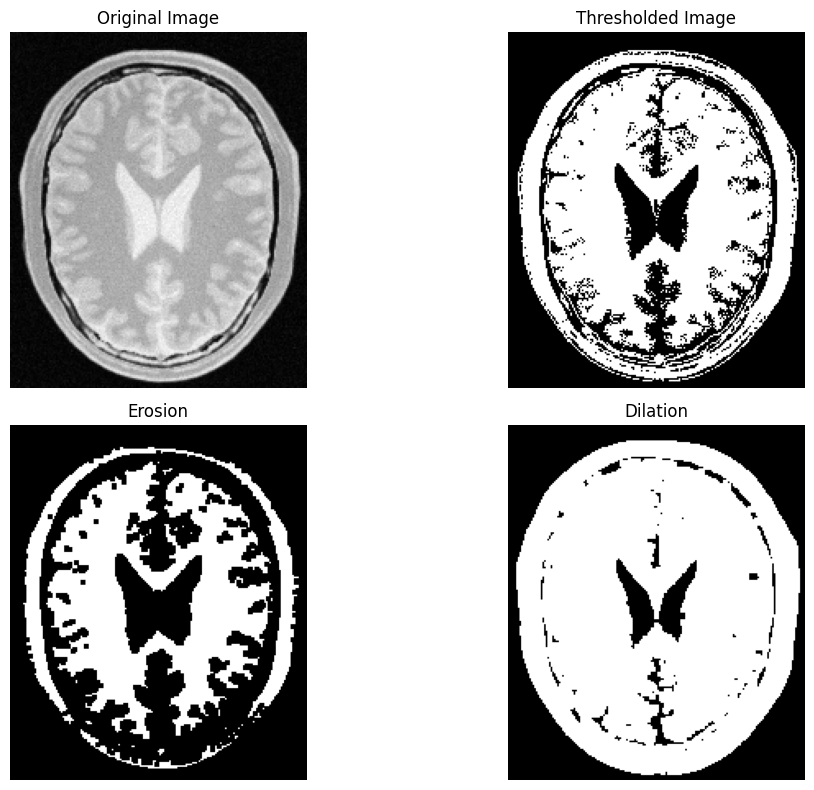

In [ ]:
# Considering thresholded image
thresholded = thresholded_image

# Apply morphological operations
kernel = np.ones((3, 3), np.uint8)

eroded = cv2.erode(thresholded, kernel, iterations=1)  # Erosion

dilated = cv2.dilate(thresholded, kernel, iterations=1) # Dilation

# Display results
titles = ['Original Image', 'Thresholded Image', 'Erosion', 'Dilation']
images = [input_image, thresholded, eroded, dilated]

plt.figure(figsize=(12, 8))
for i in range(len(images)):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
